In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from attr import dataclass
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

In [48]:
df = pd.read_csv('week3_data.csv', skiprows=1, names=['x1', 'x2', 'y'])
pf = PolynomialFeatures(degree=5, include_bias=False)

X = pf.fit_transform(df[['x1', 'x2']])
y = df['y']

In [49]:
kf = KFold(n_splits=5)
lasso_c_values = [5, 10, 20, 50, 80, 100, 120, 150]
lasso_scores_by_c = {}

for c in lasso_c_values:
    test_results = []
    model = Lasso(alpha=1 / (2 * c))
    for train, test in kf.split(X, y):
        model.fit(X[train], y[train])
        y_pred = model.predict(X[test])
        test_results.append(mean_squared_error(y[test], y_pred))
    lasso_scores_by_c[c] = np.array(test_results)

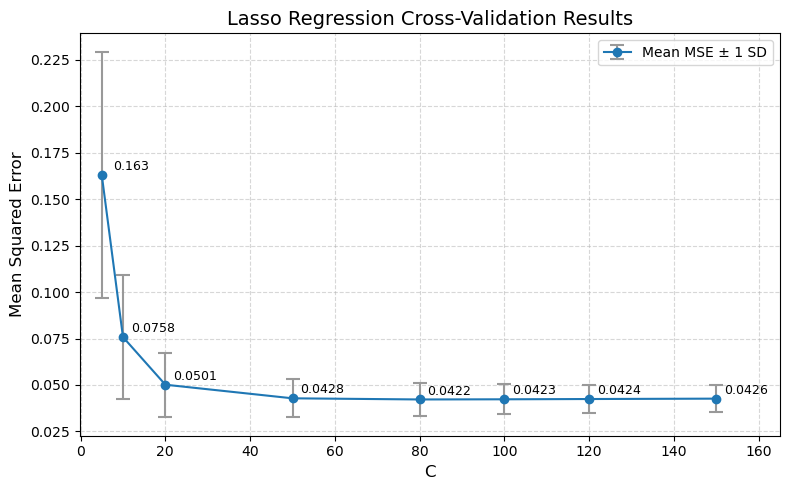

In [50]:
means = [scores.mean() for scores in lasso_scores_by_c.values()]
stds = [scores.std() for scores in lasso_scores_by_c.values()]

plt.figure(figsize=(8, 5))
main_color = '#1f77b4'
error_color = '#999999'
plt.errorbar(
    lasso_c_values, means, yerr=stds,
    fmt='o-',
    capsize=5,
    elinewidth=1.5, capthick=1.5,
    color=main_color, ecolor=error_color,
    label='Mean MSE ± 1 SD'
)

for x_cor, y_cor in zip(lasso_c_values, means):
    plt.text(x_cor + 7, y_cor + 0.001, f'{round(y_cor, 4)}', ha='center', va='bottom', fontsize=9)

plt.xlabel('C', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Lasso Regression Cross-Validation Results', fontsize=14)
plt.xlim(-0.1, 165)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(loc='best')
plt.show()

In [59]:
baseline_scores = []
for train, test in kf.split(X, y):
    baseline_model = LinearRegression()
    baseline_model.fit(X[train], y[train])
    pred = baseline_model.predict(X[test])
    baseline_scores.append(mean_squared_error(y[test], pred))

lasso_mse, lasso_std = lasso_scores_by_c[80].mean(), lasso_scores_by_c[80].std()
baseline_scores = np.array(baseline_scores)
baseline_mse, baseline_std = baseline_scores.mean(), baseline_scores.std()

print(f'Linear Regression, MSE: {round(baseline_mse, 6)}, STD: {round(baseline_std, 6)}')
print(f'Lasso C=80, MSE: {round(lasso_mse, 6)}, STD: {round(lasso_std, 6)}')

Linear Regression, MSE: 0.051302, STD: 0.012088
Lasso C=80, MSE: 0.042186, STD: 0.008703


In [52]:
ridge_c_values = [0.01, 0.1, 0.5, 1, 2, 3]
ridge_scores_by_c = {}

for c in ridge_c_values:
    test_results = []
    model = Ridge(alpha=1 / (2 * c))
    for train, test in KFold(n_splits=5).split(X, y):
        model.fit(X[train], y[train])
        y_pred = model.predict(X[test])
        mse = mean_squared_error(y[test], y_pred)
        test_results.append(mse)
    ridge_scores_by_c[c] = np.array(test_results)

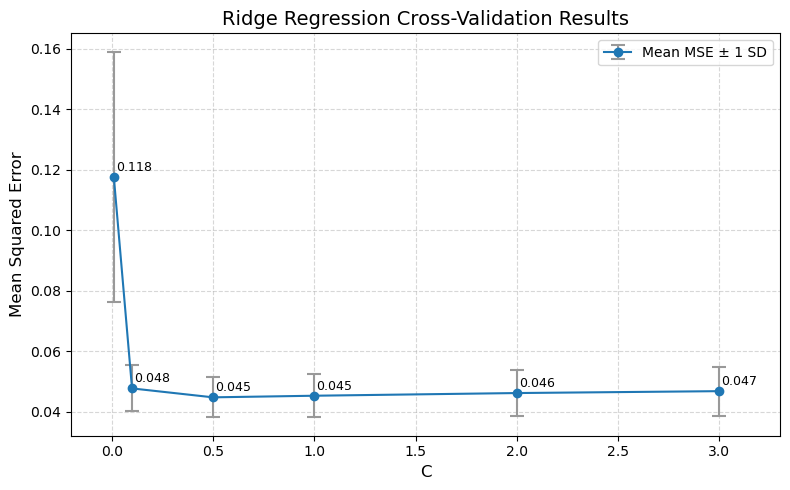

In [53]:
means = [scores.mean() for scores in ridge_scores_by_c.values()]
stds = [scores.std() for scores in ridge_scores_by_c.values()]

plt.figure(figsize=(8, 5))
plt.errorbar(
    ridge_c_values, means, yerr=stds,
    fmt='o-',
    capsize=5,
    elinewidth=1.5, capthick=1.5,
    color=main_color, ecolor=error_color,
    label='Mean MSE ± 1 SD'
)

for x_cor, y_cor in zip(ridge_c_values, means):
    plt.text(x_cor + 0.1, y_cor + 0.001, f'{round(y_cor, 3)}', ha='center', va='bottom', fontsize=9)

plt.xlabel('C', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.xlim(-0.2, 3.3)
plt.title('Ridge Regression Cross-Validation Results', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(loc='best')
plt.show()

In [61]:
ridge_mse = ridge_scores_by_c[0.5].mean()
ridge_std = ridge_scores_by_c[0.5].std()

print(f'Linear Regression, MSE: {round(baseline_mse, 6)}, STD: {round(baseline_std, 6)}')
print(f'Ridge C=0.5, MSE: {round(ridge_mse, 6)}, STD: {round(ridge_std, 6)}')


Linear Regression, MSE: 0.051302, STD: 0.012088
Ridge C=0.5, MSE: 0.044746, STD: 0.006648
